# 2. A static vine copula: one fit, fully explained

**What you will do**

1. Turn one window of returns into uniform numbers (the *marginal transform*).
2. Fit a vine copula to them and read the result: which pair-copula families were chosen, how strong the dependence
   is, how the vine is wired.
3. Compare model options (truncation, allowed families) and generate new data from the fitted model.

**Before you start:** notebook 1 (or at least a working data download). Fitting one vine takes about two seconds.

**The idea in one paragraph.** A copula describes how assets move *together*, separate from how each moves alone. For that
we first turn each asset's returns into ranks scaled to (0, 1), so only the ordering of days remains. A *vine*
then builds the joint dependence of all assets from many simple two-asset pieces ("pair-copulas") arranged in trees:
tree 1 links pairs of assets, tree 2 links pairs of those links given a third asset, and so on.

In [1]:
import os, warnings
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":      # notebooks run from the notebooks/ folder; the project root is one level up
    ROOT = ROOT.parent
os.chdir(ROOT)                    # all paths below are relative to the project folder
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.width", 140); pd.set_option("display.max_columns", 30)
print("working folder:", Path.cwd().name)

working folder: Quant_copula


In [2]:
from vine_risk.config import load_config
from vine_risk.pipeline import load_prices_and_returns

cfg = load_config("configs/default.yaml")
prices, returns = load_prices_and_returns(cfg)
window = returns.iloc[-250:]            # the last 250 trading days, the default window of the project
print(f"window: {window.index[0].date()} to {window.index[-1].date()}, shape {window.shape}")

window: 2025-10-06 to 2026-10-02, shape (250, 8)


## 2.1 Marginals: returns to uniform numbers

`EmpiricalMarginal` replaces each return by its rank divided by (T + 1), so every asset becomes (approximately)
uniform on (0, 1). This is the simple, robust choice made for this project. The class has the same interface any other
marginal model would have (`fit`, `transform`, `inverse_transform`), so a Student-t or GARCH marginal could replace it
later without touching the copula code.

In [3]:
from vine_risk.marginals import EmpiricalMarginal, uniformity_report

u = EmpiricalMarginal().fit_transform(window)
print("same as ranks / (T+1):", np.allclose(u, window.rank() / (len(window) + 1)))
u.head()

same as ranks / (T+1): True


,AAPL,MSFT,NVDA,JPM,XOM,JNJ,SPY,TLT
Date,,,,,,,,
2025-10-06,0.286853,0.904382,0.286853,0.525896,0.669323,0.338645,0.649402,0.095618
2025-10-07,0.446215,0.290837,0.434263,0.298805,0.470120,0.593625,0.254980,0.860558
2025-10-08,0.681275,0.545817,0.824701,0.183267,0.406375,0.605578,0.756972,0.569721
2025-10-09,0.103586,0.374502,0.780876,0.617530,0.223108,0.705179,0.314741,0.458167
2025-10-10,0.023904,0.107570,0.015936,0.135458,0.087649,0.386454,0.003984,0.992032


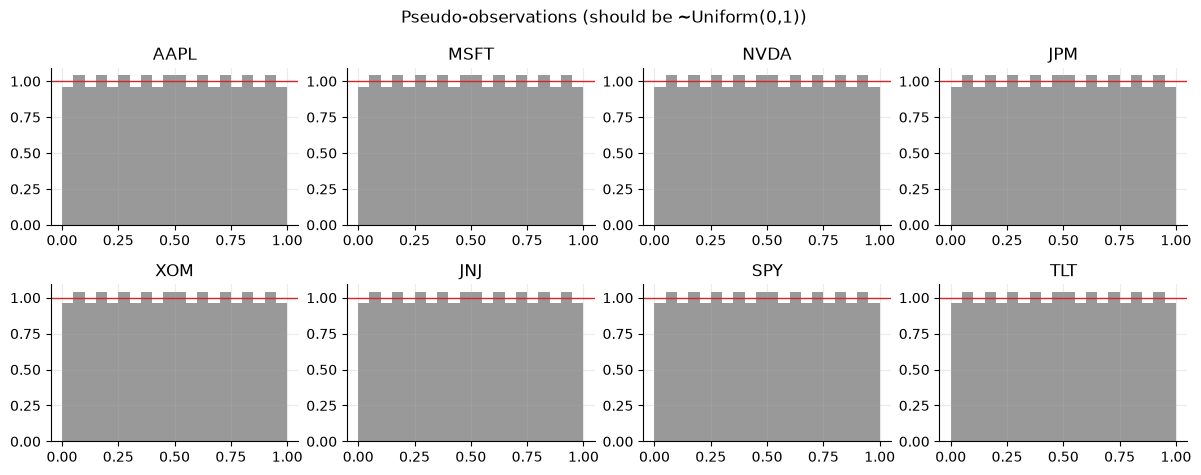

,AAPL,MSFT,NVDA,JPM,XOM,JNJ,SPY,TLT
ks_stat,0.004,0.004,0.004,0.004,0.004,0.004,0.004,0.004
p_value,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


In [4]:
from vine_risk.visualization import plot_uniformity

plot_uniformity(u); plt.show()
uniformity_report(u).round(3).T

Each histogram is flat, as it should be. The *dependence* is what is left: plot two assets against each other on this
uniform scale. If they were independent the dots would fill the square evenly.

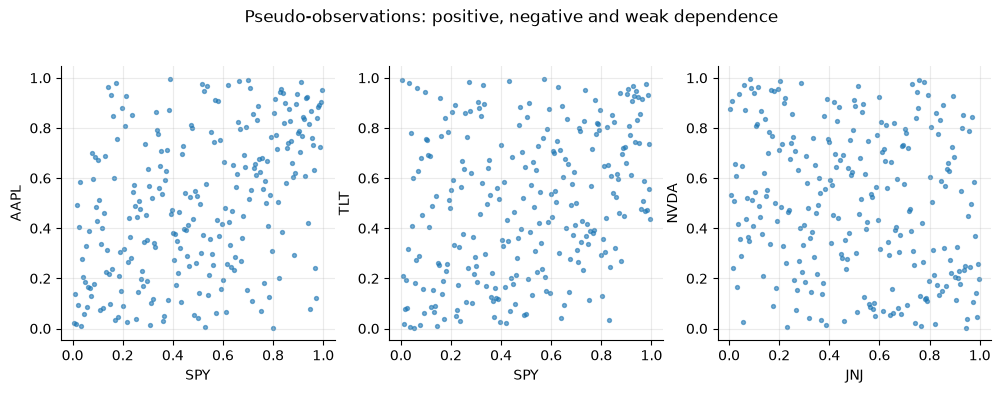

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (a, b) in zip(axes, [("SPY", "AAPL"), ("SPY", "TLT"), ("JNJ", "NVDA")]):
    ax.scatter(u[a], u[b], s=8, alpha=0.6); ax.set_xlabel(a); ax.set_ylabel(b); ax.set_aspect("equal")
fig.suptitle("Pseudo-observations: positive, negative and weak dependence"); plt.show()

## 2.2 Fit the vine

`VineCopula(...).fit(u, returns)` finds the tree structure and chooses a copula family for every pair (by BIC, which
penalises complexity). `truncation_level=3` means that only the first three trees are fitted, which is the project's
default: the deeper trees are small and mostly noise.

`summary()` turns the fitted model into a plain, serialisable result object (we never store the C++ model itself).

In [6]:
from vine_risk.copula import VineCopula

vine = VineCopula(truncation_level=3).fit(u, window)
res = vine.summary()
print(f"{res.n_assets} assets, {res.n_obs} observations, window {res.window_start} to {res.window_end}")
print(f"log-likelihood {res.loglik:.1f} | AIC {res.aic:.1f} | BIC {res.bic:.1f} | parameters {res.n_params:.0f} | status {res.status}")

8 assets, 250 observations, window 2025-10-06 to 2026-10-02
log-likelihood 210.7 | AIC -395.3 | BIC -349.6 | parameters 13 | status ok


In [7]:
pcs = res.pair_copula_frame()
cols = ["tree", "conditioned", "conditioning", "family", "rotation", "parameters", "tau", "lower_tail", "upper_tail"]
pcs[pcs.tree == 1][cols].round(3)

,tree,conditioned,conditioning,family,rotation,parameters,tau,lower_tail,upper_tail
0,1,"(JNJ, MSFT)",(),gaussian,0,[-0.22729096423957332],-0.146,0.000,0.0
1,1,"(AAPL, SPY)",(),frank,0,[2.7356034564917526],0.284,0.000,0.0
2,1,"(MSFT, SPY)",(),frank,0,[2.8174860496663046],0.291,0.000,0.0
3,1,"(JPM, SPY)",(),gaussian,0,[0.464764759230959],0.308,0.000,0.0
4,1,"(XOM, TLT)",(),gaussian,0,[-0.3845766599073352],-0.251,0.000,0.0
5,1,"(TLT, SPY)",(),tawn,180,"[0.9999999999844356, 0.3000009466826125, 1.841...",0.194,0.242,0.0
6,1,"(SPY, NVDA)",(),gumbel,180,[1.7805392675494007],0.438,0.524,0.0


Reading tree 1: each row is a direct link between two assets. `family` is the chosen building block (for example
*gaussian*, *student*, *clayton* or *gumbel*), `tau` is its Kendall's tau (rank correlation, from -1 to 1), and
`lower_tail` / `upper_tail` are its **tail dependence coefficients**: the probability, in the limit, that one asset is
extremely low (high) when the other is. Gaussian and Frank pairs have none; Clayton has lower-tail dependence only,
Gumbel upper-tail only, Student-t both.

Higher trees describe **conditional** dependencies, the dependence between two assets *after* accounting for others
(`conditioning` column). Their tau and tail values are conditional too.

In [8]:
pcs[pcs.tree == 2][cols].round(3).head(6)

,tree,conditioned,conditioning,family,rotation,parameters,tau,lower_tail,upper_tail
7,2,"(JNJ, SPY)","(MSFT,)",independence,0,[],0.000,0.0,0.0
8,2,"(AAPL, NVDA)","(SPY,)",frank,0,[-1.4710431232737593],-0.160,0.0,0.0
9,2,"(MSFT, JPM)","(SPY,)",clayton,270,[0.20369045237009498],-0.092,0.0,0.0
10,2,"(JPM, NVDA)","(SPY,)",frank,0,[-1.5052636455779376],-0.164,0.0,0.0
11,2,"(XOM, SPY)","(TLT,)",gumbel,90,[1.150191172681614],-0.131,0.0,0.0
12,2,"(TLT, NVDA)","(SPY,)",independence,0,[],0.000,0.0,0.0


In [9]:
pcs.groupby("tree")["family"].value_counts().unstack(fill_value=0)

family,clayton,frank,gaussian,gumbel,independence,tawn
tree,,,,,,
1,0,2,3,1,0,1
2,1,2,0,1,2,0
3,0,0,0,0,5,0


## 2.3 Dependence on the usual scale

Kendall's tau of every pair, straight from the data (the matrix below is symmetric with ones on the diagonal), and the
fitted vine drawn tree by tree:

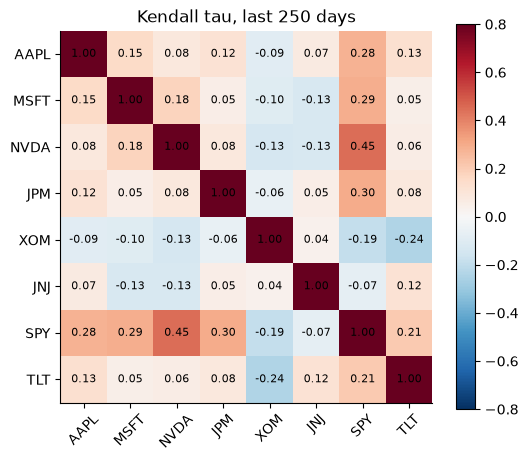

In [10]:
tau = res.tau_matrix()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(tau, cmap="RdBu_r", vmin=-0.8, vmax=0.8); ax.grid(False)
ax.set_xticks(range(len(tau))); ax.set_xticklabels(tau.columns, rotation=45)
ax.set_yticks(range(len(tau))); ax.set_yticklabels(tau.index)
for i in range(len(tau)):
    for j in range(len(tau)):
        ax.text(j, i, f"{tau.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im); ax.set_title("Kendall tau, last 250 days"); plt.show()

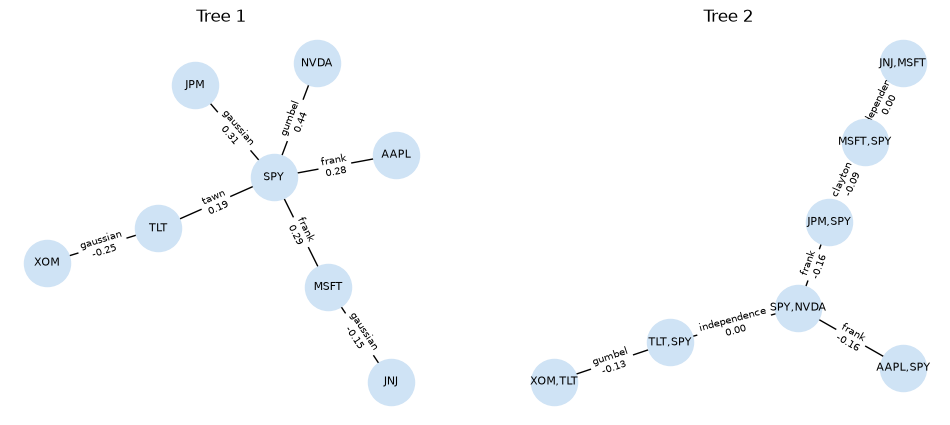

In [11]:
from vine_risk.visualization import plot_vine_tree

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_vine_tree(res, 1, ax=axes[0]); plot_vine_tree(res, 2, ax=axes[1])
plt.show()

Tree 1 usually has a hub (here: the market index SPY connects most stocks). Tree 2 nodes are the edges of tree 1, and
its edges are the conditional links. Hover-able versions of these plots are in the dashboard (`streamlit run dashboard/app.py`).

## 2.4 Model-implied dependence for *every* pair

Pair-copulas beyond tree 1 are conditional, so they cannot answer "how dependent are assets A and B, overall?". For that,
`summary()` simulates from the fitted vine and measures every pair: `model_tau` (Kendall's tau), `lower_tail_q` and
`upper_tail_q`, the probability that both assets are in their worst (best) 5 % of days given that one is.
These are finite-level tail coefficients, not the textbook limits, and are positive even for Gaussian pairs.

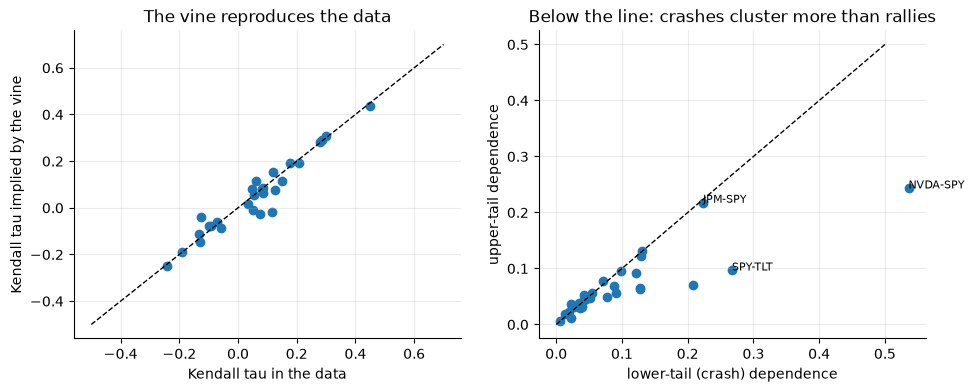

,pair,tau,model_tau,lower_tail_q,upper_tail_q
16,NVDA-SPY,0.449,0.438,0.536,0.243
27,SPY-TLT,0.209,0.194,0.267,0.096
20,JPM-SPY,0.299,0.308,0.223,0.217
17,NVDA-TLT,0.060,0.116,0.209,0.071
11,MSFT-SPY,0.288,0.291,0.131,0.132


In [12]:
pw = res.pairwise_frame()
pw["pair"] = pw.asset_i + "-" + pw.asset_j
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(pw.tau, pw.model_tau); axes[0].plot([-.5, .7], [-.5, .7], "k--", lw=1)
axes[0].set_xlabel("Kendall tau in the data"); axes[0].set_ylabel("Kendall tau implied by the vine"); axes[0].set_title("The vine reproduces the data")
axes[1].scatter(pw.lower_tail_q, pw.upper_tail_q)
for _, r in pw.nlargest(3, "lower_tail_q").iterrows(): axes[1].annotate(r.pair, (r.lower_tail_q, r.upper_tail_q), fontsize=8)
axes[1].plot([0, .5], [0, .5], "k--", lw=1); axes[1].set_xlabel("lower-tail (crash) dependence"); axes[1].set_ylabel("upper-tail dependence")
axes[1].set_title("Below the line: crashes cluster more than rallies"); plt.show()
pw.sort_values("lower_tail_q", ascending=False)[["pair", "tau", "model_tau", "lower_tail_q", "upper_tail_q"]].head(5).round(3)

## 2.5 Simulating from the model

A fitted copula can generate new data with the same dependence. This is the engine behind the portfolio risk
(notebook 5). Below, 5,000 simulated days are compared with the 250 real ones for one pair.

largest difference in tau between real and simulated data: 0.116 (250 days is a small sample, and the truncated vine is an approximation)


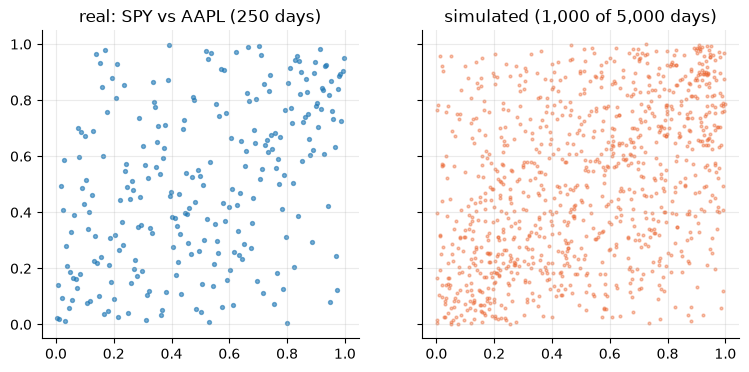

In [13]:
from vine_risk.dependence import pairwise_dependence

sim = vine.simulate(5000, seed=1)            # the seed makes the result reproducible
emp = pairwise_dependence(u).set_index(["asset_i", "asset_j"]).tau
mod = pairwise_dependence(sim).set_index(["asset_i", "asset_j"]).tau
print("largest difference in tau between real and simulated data:", round((emp - mod).abs().max(), 3),
      "(250 days is a small sample, and the truncated vine is an approximation)")

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharex=True, sharey=True)
axes[0].scatter(u.SPY, u.AAPL, s=8, alpha=.6); axes[0].set_title("real: SPY vs AAPL (250 days)")
axes[1].scatter(sim.SPY.iloc[:1000], sim.AAPL.iloc[:1000], s=4, alpha=.4, color="#eb6834"); axes[1].set_title("simulated (1,000 of 5,000 days)")
plt.show()

## 2.6 Model options

A few switches change what is fitted. The table compares them on the same data. Remember that more parameters always
fit better; **BIC** (lower is better) charges for them.

In [14]:
options = {
    "all families, full vine": dict(),
    "all families, truncated at tree 3 (project default)": dict(truncation_level=3),
    "all families, truncated at tree 1": dict(truncation_level=1),
    "Gaussian pairs only (no tail dependence)": dict(truncation_level=3, families=["indep", "gaussian"]),
}
rows = []
for label, kw in options.items():
    r = VineCopula(tail_simulations=0, **kw).fit(u).summary()
    rows.append({"model": label, "log-likelihood": r.loglik, "parameters": r.n_params, "AIC": r.aic, "BIC": r.bic})
pd.DataFrame(rows).set_index("model").round(1)

,log-likelihood,parameters,AIC,BIC
model,,,,
"all families, full vine",223.3,16.0,-414.6,-358.3
"all families, truncated at tree 3 (project default)",210.7,13.0,-395.3,-349.6
"all families, truncated at tree 1",186.9,9.0,-355.9,-324.2
Gaussian pairs only (no tail dependence),192.2,10.0,-364.4,-329.2


Reading the table (lower BIC is better): the vine with all families beats the Gaussian-only vine, which is some evidence of
non-Gaussian dependence (tail dependence) in the data. Cutting the vine after tree 1 loses a lot. The full vine has a slightly
better BIC than the one truncated at tree 3; the project truncates anyway because the fit is about three times faster and the
deeper trees mainly describe small conditional effects that are hard to estimate from 250 days. You can set
`truncation_level=None` in the config to fit full vines. Try `selection_criterion="aic"` or `tree_criterion="rho"` too.

## 2.7 Saving a result

Results convert to JSON and back without loss, which is how the rolling run stores one fit per day.

In [15]:
from vine_risk.copula import VineFitResult

text = res.to_json()
back = VineFitResult.from_json(text)
print(len(text) // 1000, "KB of JSON | round trip exact:", back.to_json() == text)

12 KB of JSON | round trip exact: True


Next: `03_rolling_vine.ipynb`, repeating this fit for every day of the history.